In [5]:

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report

Step 1

In [6]:
# 1. LOAD AND PREPROCESS THE CIFAR-10 DATASET
# ─────────────────────────────────────────────────────────
print("Loading data...")
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# CIFAR-10 classes
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Convert labels to one-hot encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# VGG16 expects images at least 32x32, which CIFAR-10 is.
# However, for better features, we'll keep the input shape at (32, 32, 3).
x_train_resized = x_train
x_test_resized = x_test

Loading data...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [7]:
# 2. LOAD PRE-TRAINED VGG16 (WITHOUT TOP LAYERS)
# ─────────────────────────────────────────────────────────
# We use include_top=False to remove the original 1000-class classifier
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# Freeze the convolutional layers to retain pre-trained features
base_model.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
# 3. CREATE A CUSTOM MODEL FOR CIFAR-10
# ─────────────────────────────────────────────────────────
model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

In [9]:
# 4. COMPILE & TRAIN THE MODEL
# ─────────────────────────────────────────────────────────
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

print("\nStarting Training (Shortened for speed)...")
history = model.fit(
    x_train_resized, y_train_cat,
    epochs=2,              # Reduced to finish within ~5 mins
    batch_size=128,        # Increased batch size for faster processing
    validation_split=0.2,
    verbose=1
)


Starting Training (Shortened for speed)...
Epoch 1/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.2412 - loss: 2.1128 - val_accuracy: 0.4294 - val_loss: 1.7570
Epoch 2/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - accuracy: 0.3922 - loss: 1.7447 - val_accuracy: 0.4821 - val_loss: 1.5667


In [10]:
# 5. EVALUATE THE MODEL
# ─────────────────────────────────────────────────────────
print("\nEvaluating Model...")
test_loss, test_acc = model.evaluate(x_test_resized, y_test_cat, verbose=0)
print(f'Test Accuracy: {test_acc:.4f}  |  Test Loss: {test_loss:.4f}')

y_pred_probs = model.predict(x_test_resized, batch_size=128)
y_pred = np.argmax(y_pred_probs, axis=1)

print('\nClassification Report:')
print(classification_report(y_test.flatten(), y_pred, target_names=CLASS_NAMES))




Evaluating Model...
Test Accuracy: 0.4757  |  Test Loss: 1.5768
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step

Classification Report:
              precision    recall  f1-score   support

    airplane       0.57      0.57      0.57      1000
  automobile       0.50      0.54      0.51      1000
        bird       0.38      0.31      0.34      1000
         cat       0.37      0.29      0.33      1000
        deer       0.47      0.43      0.45      1000
         dog       0.46      0.45      0.46      1000
        frog       0.48      0.62      0.55      1000
       horse       0.47      0.49      0.48      1000
        ship       0.55      0.59      0.57      1000
       truck       0.45      0.47      0.46      1000

    accuracy                           0.48     10000
   macro avg       0.47      0.48      0.47     10000
weighted avg       0.47      0.48      0.47     10000



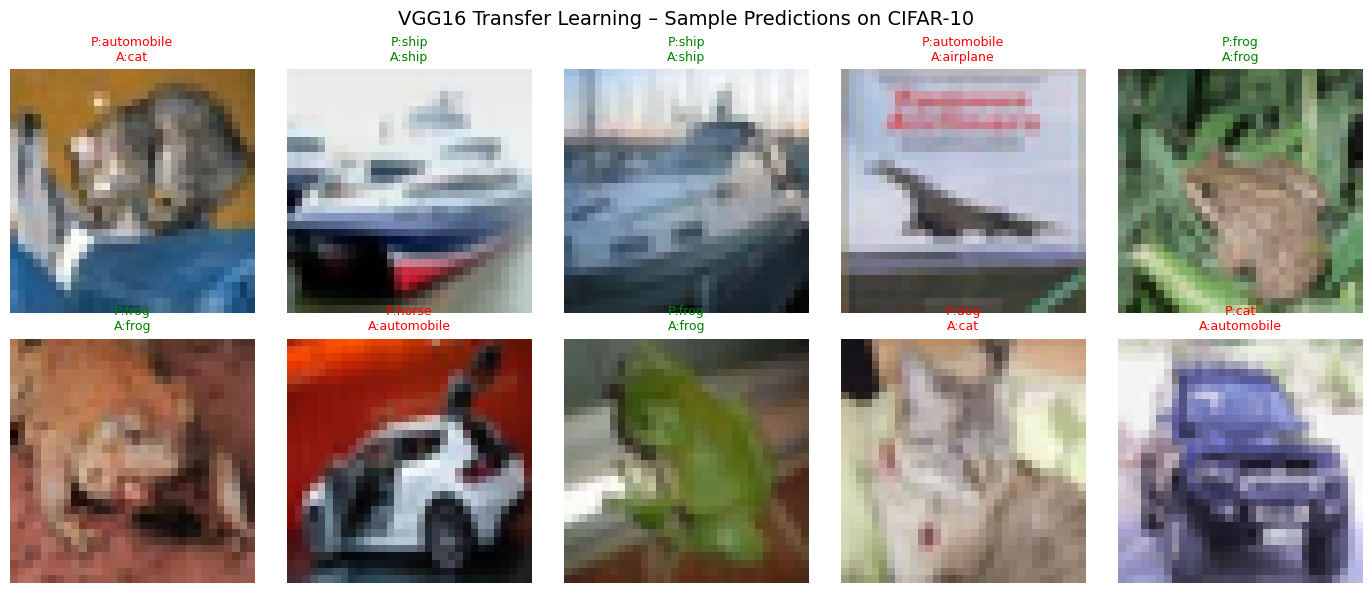

In [11]:
# 6. VISUALIZE SAMPLE PREDICTIONS
# ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('VGG16 Transfer Learning – Sample Predictions on CIFAR-10', fontsize=14)

for i, ax in enumerate(axes.flat):
    ax.imshow(x_test[i])
    pred_label = CLASS_NAMES[y_pred[i]]
    actual_label = CLASS_NAMES[y_test[i][0]]

    color = 'green' if pred_label == actual_label else 'red'
    ax.set_title(f'P:{pred_label}\nA:{actual_label}', color=color, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('predictions.png', dpi=150)
plt.show()

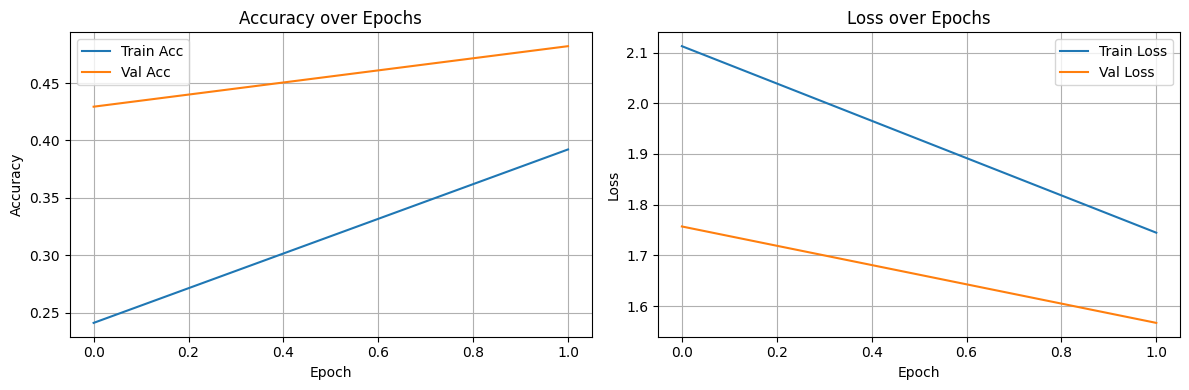

In [12]:
# 7. PLOT TRAINING & VALIDATION ACCURACY / LOSS
# ─────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Train Acc')
ax1.plot(history.history['val_accuracy'], label='Val Acc')
ax1.set_title('Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('accuracy_loss.png', dpi=150)
plt.show()